# 手引き: アライメント計測Markの選び方の比較（Python版）

ブラウザ版（`index.html`）と**同じ計算・同じ乱数**で評価します。同じ設定なら、同じ点が選ばれ、同じ残差になります。

- **対象**: アライメント計測のサンプリングを検討する技術者
- **前提**: Python を少し読めること（関数を呼んで結果を見る程度）
- **できるようになること**
  - 初期設定、またはアプリで保存した設定JSONで評価する
  - 制約付きD最適・I最適の計測点（計画）だけをすぐに作り、座標をCSVで保存する
  - 現行のサンプリングを「手動プラン」として、制約なし・制約付きのD最適・I最適などと比べる
  - 計測Mark数と精度のトレードオフカーブを描く

## 流れ

1. 準備
2. 設定を決める（初期設定か、アプリで保存した設定JSON）
3. Waferマップと評価データを作る
4. 手動プラン（現行のサンプリング）と、制約付きD・I最適の計画を作る
5. 評価を実行する
6. 表で見る（残差・D/I基準・制約の満たし具合）
7. 図で見る（箱ひげ図・選んだ点・推定誤差のマップ）
8. 計測点数のスイープ（トレードオフカーブ）
9. 結果をCSVで保存する

## 1. 準備

`python/` フォルダの仮想環境（`.venv`）でこのノートブックを開きます。表は小さなHTMLの表で出します。

In [1]:
import csv
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd().parent))  # python/ フォルダの alignment_sampling を読む
import alignment_sampling as asc
from alignment_sampling import plots

print("日本語フォント:", plots.use_japanese_font())
OUTPUT_DIRECTORY = Path("output")  # CSVの保存先（Gitの管理外）
OUTPUT_DIRECTORY.mkdir(exist_ok=True)


def show_table(headers, rows):
    """小さな表を出す（値は文字にして渡す）。"""
    head = "".join(f"<th>{h}</th>" for h in headers)
    body = "".join("<tr>" + "".join(f"<td>{c}</td>" for c in row) + "</tr>" for row in rows)
    display(HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"))


def fmt(value, digits=3):
    return "—" if value is None or not math.isfinite(value) else f"{value:.{digits}f}"

日本語フォント: Hiragino Sans


## 2. 設定を決める

- 初期設定はアプリの初期設定と同じです（Wafer 100枚、計測Shot 20個、試行30回、制約はすべてハード、Scan方向は一筆書き）。
- 選んだShotでは、そのShotに紐づくMark（有効範囲の中にあるもの）をすべて測ります。Markが揃わない端のShotを選ばないときは `settings["sampling"]["excludeIncompleteShots"] = True` にします。
- 強制計測Shot・除外Shotは `settings["constraints"]["mandatoryShotIds"]`・`["excludedShotIds"]` にShot番号の文字の一覧で入れます。
- アプリの「設定をJSONで保存」で作ったファイルがあれば、`SETTINGS_FILE` に置き場所を書くと、そのまま読み込みます（CSVのマップや手動プランも入ります）。

In [2]:
SETTINGS_FILE = None  # 例: Path("設定_20261004-1200.json")

if SETTINGS_FILE:
    loaded = asc.load_settings_file(SETTINGS_FILE)
    settings = loaded["settings"]
    wafer_map = asc.map_from_loaded(loaded)
    manual_from_file = asc.manual_plan_inputs(loaded["manual"], wafer_map)
else:
    settings = asc.default_settings()
    wafer_map = asc.generate_wafer_map(settings["map"])
    manual_from_file = []

# ここで設定を変えられる（例: Wafer数、試行回数、計測Shot数）
settings["evaluationData"]["waferCount"] = 100
settings["sampling"]["draws"] = 30
print("計測Shot数:", settings["sampling"]["shotCount"], "／ 端のShotを選ばない:", settings["sampling"]["excludeIncompleteShots"])
print("強制計測Shot:", settings["constraints"]["mandatoryShotIds"] or "なし", "／ 除外Shot:", settings["constraints"]["excludedShotIds"] or "なし")

計測Shot数: 20 ／ 端のShotを選ばない: False
強制計測Shot: なし ／ 除外Shot: なし


## 3. Waferマップと評価データ

評価データは、Zernike（Fringe Z1〜Z36）の乱数係数で作るWafer高次傾向と計測ノイズです。乱数シードが同じなら、アプリと同じ値になります。

In [3]:
data = asc.generate_evaluation_data(wafer_map, settings["evaluationData"])
print(f"Shot {len(wafer_map['shots'])}個、有効なMark {len(wafer_map['marks'])}個、Wafer {data['waferCount']}枚")
print(f"真のずれ X のRMS（全Wafer）: {np.sqrt((data['truthX'] ** 2).mean()):.3f} nm")

Shot 104個、有効なMark 332個、Wafer 100枚
真のずれ X のRMS（全Wafer）: 2.267 nm


## 4. 手動プラン（現行のサンプリング）を作る

Shot番号（アプリやCSVの ShotId）の一覧から作ります。ここでは例として、Wafer全体に散らした20Shotを使います。実際の現行サンプリングのShot番号に置き換えてください。

除外Shot（と、端のShotを選ばない設定のときの端のShot）は評価から外れ、警告が出ます。

In [4]:
current_shot_ids = ["11", "13", "20", "26", "31", "34", "37", "39", "45", "48", "55", "58", "62", "66", "70", "73", "80", "85", "92", "94"]
manual_plans = [asc.plan_from_shot_ids("現行（例）", current_shot_ids, wafer_map, key="manual:1")] + manual_from_file
for plan in manual_plans:
    print(plan["label"], "：Shot", len(plan["shotIndices"]), "個")

現行（例） ：Shot 20 個


### 4-2 制約付きD最適・I最適の計画を作る（評価データを使わない）

Waferマップと制約だけから、制約付きD最適・I最適の計測点を選びます（アプリの「計画を作成」と同じ）。すぐに終わり、同じ設定なら次の評価の制約付きD最適・I最適と同じ点になります。選んだ点の座標は `selection_to_csv` で1行1MarkのCSVにできます。

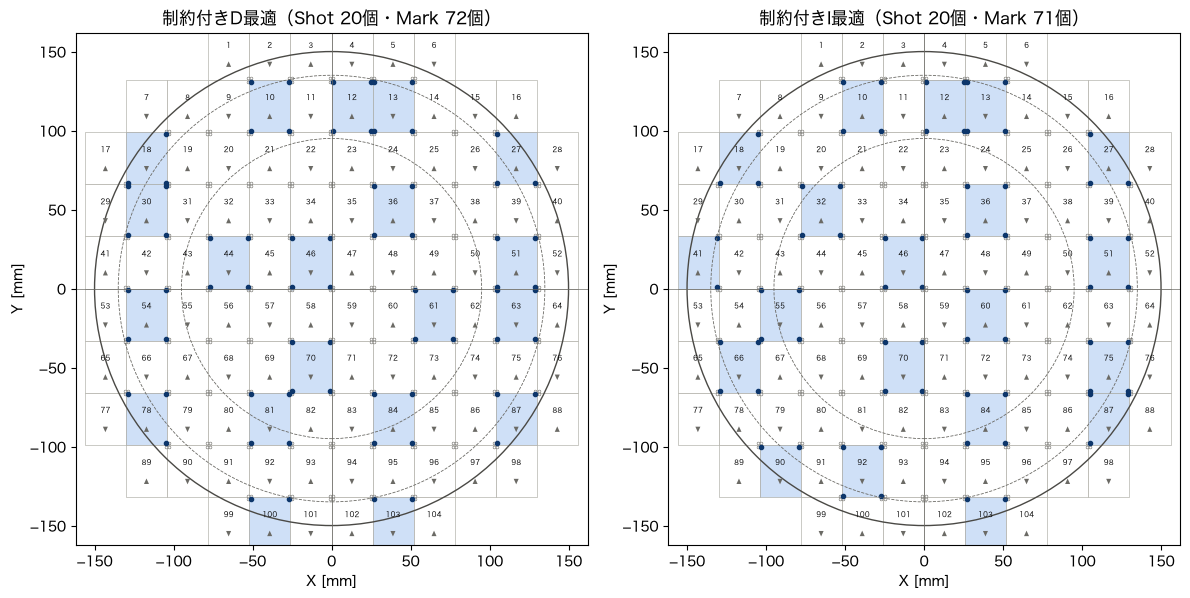

選べなかった選び方: なし ／ 保存: ['plan_constrainedD.csv', 'plan_constrainedI.csv']


In [5]:
design_plan = asc.run_plan(wafer_map, settings)
mandatory_shots = [design_plan["context"]["items"][item]["shotIndex"] for item in design_plan["context"]["mandatoryItems"]]
figure, axes = plt.subplots(1, len(design_plan["sets"]), figsize=(6 * len(design_plan["sets"]), 6))
for ax, entry in zip(np.atleast_1d(axes), design_plan["sets"]):
    label = next(m["label"] for m in design_plan["methods"] if m["key"] == entry["method"])
    plots.plot_selection_map(wafer_map, entry, title=f"{label}（Shot {len(entry['shotIndices'])}個・Mark {len(entry['markIndices'])}個）", zones=settings["zones"], ax=ax, mandatory_shot_indices=mandatory_shots)
    (OUTPUT_DIRECTORY / f"plan_{entry['method']}.csv").write_text(asc.selection_to_csv(wafer_map, entry["markIndices"]), encoding="utf-8-sig")
plt.tight_layout()
plt.show()
print("選べなかった選び方:", design_plan["failedMethods"] or "なし", "／ 保存:", sorted(p.name for p in OUTPUT_DIRECTORY.glob("plan_*.csv")))

## 5. 評価を実行する

選び方（ランダム・ポアソンディスク・D最適（制約なし）・I最適（制約なし）・制約付きD最適・制約付きI最適・手動プラン）× 補正（HOWAのみ、推定→HOWA の推定手法ごと）で、全Waferの残差を求めます。数秒かかります。

In [6]:
progress_marks = set()


def progress(done, total, label):
    percent = int(100 * done / total) // 25 * 25
    if percent not in progress_marks:
        progress_marks.add(percent)
        print(f"{percent:3d}% {label}")


output = asc.run_evaluation(wafer_map, data, settings, manual_plans, progress)
print("選び方:", [m["label"] for m in output["methods"]])
print("ソフトに切り替えた制約:", [r["label"] for r in output["relaxed"]] or "なし")
print("選べなかった選び方:", output["failedMethods"] or "なし")
for warning in dict.fromkeys(w for entry in output["sets"] for w in entry["warnings"]):
    print("警告:", warning)

  0% 計測Markを選んでいます
 25% 計測Markを選んでいます


 50% 補正して残差を求めています


 75% 補正して残差を求めています


100% 集計しています


選び方: ['ランダム', 'ポアソンディスク', 'D最適（制約なし）', 'I最適（制約なし）', '制約付きD最適', '制約付きI最適', '現行（例）']
ソフトに切り替えた制約: なし
選べなかった選び方: なし


## 6. 表で見る

### 6-1 残差（RMS・X のWafer平均）

行が選び方、列が補正です。小さいほど良い結果です。

In [7]:
AXIS, METRIC = "x", "rms"


def label_of(method):
    return method["label"] + ("（手動）" if method["manual"] else "")


rows = []
for method in output["methods"]:
    summary = output["summary"][method["key"]]
    rows.append([label_of(method)] + [fmt(summary["variants"][v["key"]][AXIS][METRIC]["all"]["mean"]) for v in output["variants"]])
show_table(["選び方"] + [v["label"] for v in output["variants"]], rows)
baseline = asc.summarize_store(output["baselines"]["allMarks"]["howa"])[AXIS][METRIC]["mean"]
print(f"全点計測（HOWAのみ）: {baseline:.3f} nm")

選び方,HOWAのみ,"RBF（X,Y）→HOWA","RBF（X,Y,半径）→HOWA","GP（X,Y）→HOWA","GP（X,Y,半径）→HOWA"
ランダム,0.620,0.682,0.664,0.662,0.610
ポアソンディスク,0.377,0.431,0.418,0.433,0.403
D最適（制約なし）,0.332,0.331,0.321,0.339,0.325
I最適（制約なし）,0.316,0.312,0.310,0.321,0.315
制約付きD最適,0.313,0.319,0.314,0.324,0.314
制約付きI最適,0.315,0.318,0.313,0.322,0.313
現行（例）（手動）,0.579,0.682,0.665,0.668,0.649


全点計測（HOWAのみ）: 0.264 nm


### 6-2 D基準・I基準と制約の満たし具合

- D基準 log₁₀det(XᵀX) は大きいほど、I基準（予測分散の平均÷σ²）は小さいほど良い選び方です。効率は、この評価の中で最も良いものを100%にした値です。
- 制約は「満たした回数 / 試行の数」と、外れたときのずれ（何個のShotを移せば満たせるか。強制計測Shotは選ばれていない数）の平均です。制約なしのD最適・I最適と手動プランは制約を守らないので、外れることがあります。

In [8]:
reference = output["criteriaReference"]["x"]
rows = []
for method in output["methods"]:
    s = output["summary"][method["key"]]
    criteria = s["criteriaX"]
    mean = {"logDet": criteria["logDet"]["mean"], "trace": criteria["trace"]["mean"], "p": len(settings["model"]["termsX"]), "singular": criteria["singularCount"] > 0}
    eff = asc.efficiencies(mean, reference)
    constraints = "、".join(f"{c['label']} {c['satisfied']}/{c['total']}" + ("" if c["satisfied"] == c["total"] else f"（ずれ {c['meanShift']:.1f}）") for c in s["constraints"])
    rows.append([label_of(method), fmt(mean["logDet"] / math.log(10), 2), f"{eff['d']:.0f}%", fmt(mean["trace"]), f"{eff['i']:.0f}%", constraints])
show_table(["選び方", "D基準", "D効率", "I基準", "I効率", "制約（満たした回数）"], rows)

選び方,D基準,D効率,I基準,I効率,制約（満たした回数）
ランダム,-13.42,54%,2.018,14%,Scan方向 30/30、4象限 30/30、同心円の3領域 30/30、中心の1点 30/30
ポアソンディスク,-10.91,71%,0.522,54%,Scan方向 30/30、4象限 30/30、同心円の3領域 30/30、中心の1点 30/30
D最適（制約なし）,-7.75,100%,0.292,96%,Scan方向 1/1、4象限 0/1（ずれ 1.0）、同心円の3領域 0/1（ずれ 6.0）、中心の1点 0/1（ずれ 1.0）
I最適（制約なし）,-7.93,98%,0.280,100%,Scan方向 0/1（ずれ 2.0）、4象限 0/1（ずれ 1.0）、同心円の3領域 0/1（ずれ 7.0）、中心の1点 0/1（ずれ 1.0）
制約付きD最適,-8.61,91%,0.306,91%,Scan方向 1/1、4象限 1/1、同心円の3領域 1/1、中心の1点 1/1
制約付きI最適,-8.66,90%,0.304,92%,Scan方向 1/1、4象限 1/1、同心円の3領域 1/1、中心の1点 1/1
現行（例）（手動）,-12.63,59%,1.277,22%,Scan方向 0/1（ずれ 4.0）、4象限 0/1（ずれ 1.0）、同心円の3領域 0/1（ずれ 6.0）、中心の1点 0/1（ずれ 1.0）


### 6-3 推定精度（未計測Markでの 推定値 − 真のずれ）

「HOWA（多項式の予測）」より小さい推定手法なら、未計測Markを当てる力が多項式より上です。

In [9]:
rows = []
for method in output["methods"]:
    s = output["summary"][method["key"]]
    rows.append([label_of(method)] + [fmt(s["estimation"][k][AXIS]["rms"]["all"]["mean"]) for k in output["estimationKeys"]])
show_table(["選び方"] + [asc.estimation_label(k) for k in output["estimationKeys"]], rows)

選び方,HOWA（多項式の予測）,"RBF（X,Y）","RBF（X,Y,半径）","GP（X,Y）","GP（X,Y,半径）"
ランダム,0.675,0.790,0.756,0.770,0.685
ポアソンディスク,0.393,0.499,0.467,0.490,0.424
D最適（制約なし）,0.351,0.350,0.329,0.368,0.318
I最適（制約なし）,0.328,0.323,0.318,0.331,0.301
制約付きD最適,0.320,0.350,0.326,0.343,0.298
制約付きI最適,0.324,0.347,0.326,0.339,0.295
現行（例）（手動）,0.646,0.793,0.771,0.759,0.725


## 7. 図で見る

### 7-1 残差の箱ひげ図（HOWAのみ と 推定→HOWA の各推定手法）

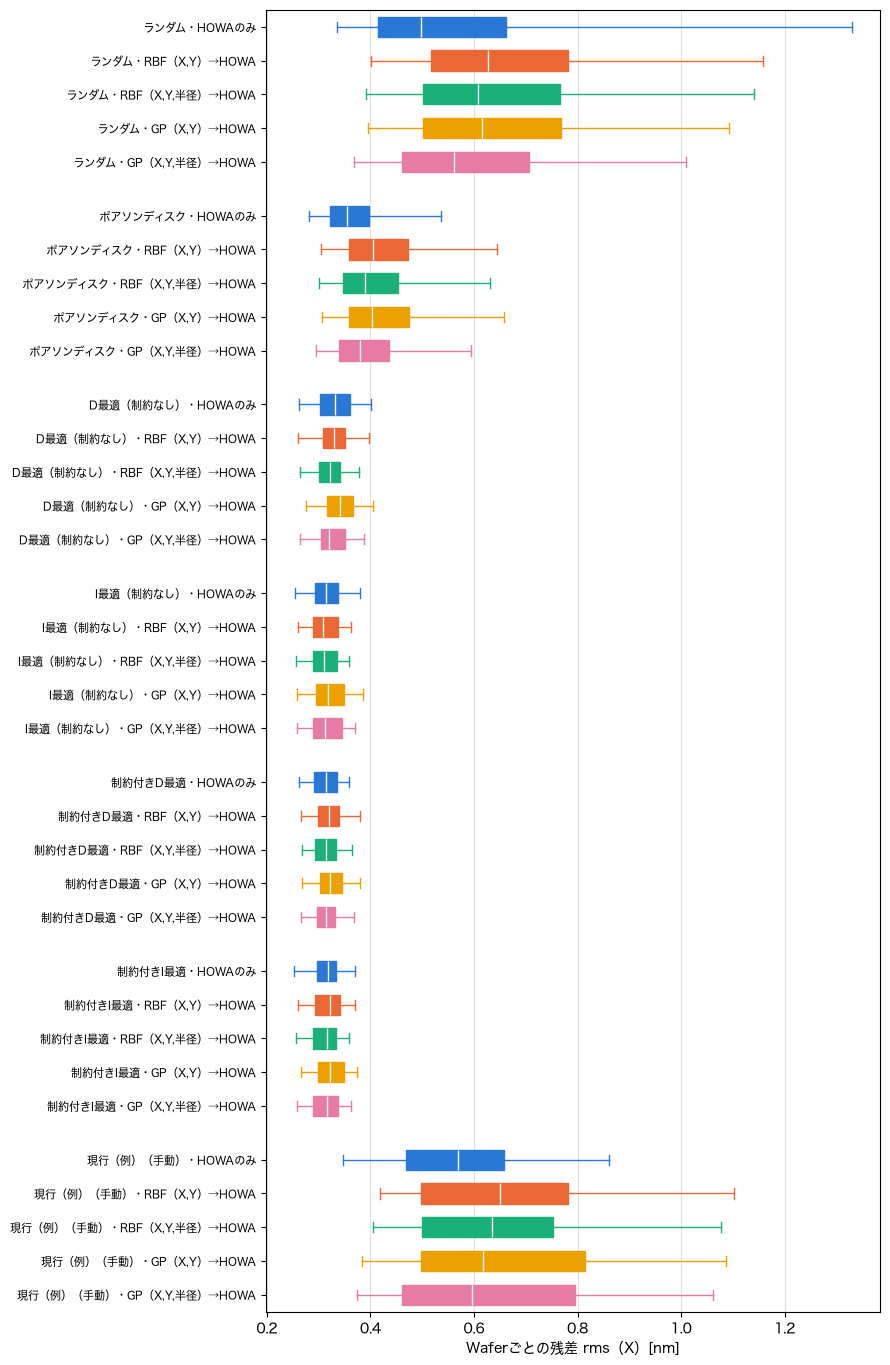

In [10]:
plots.plot_residual_boxes(output, axis="x", metric="rms")
plt.tight_layout()
plt.show()

### 7-2 選び方ごとに選んだ点

ランダム・ポアソンは、残差（HOWAのみ）が中央の試行を表示します。

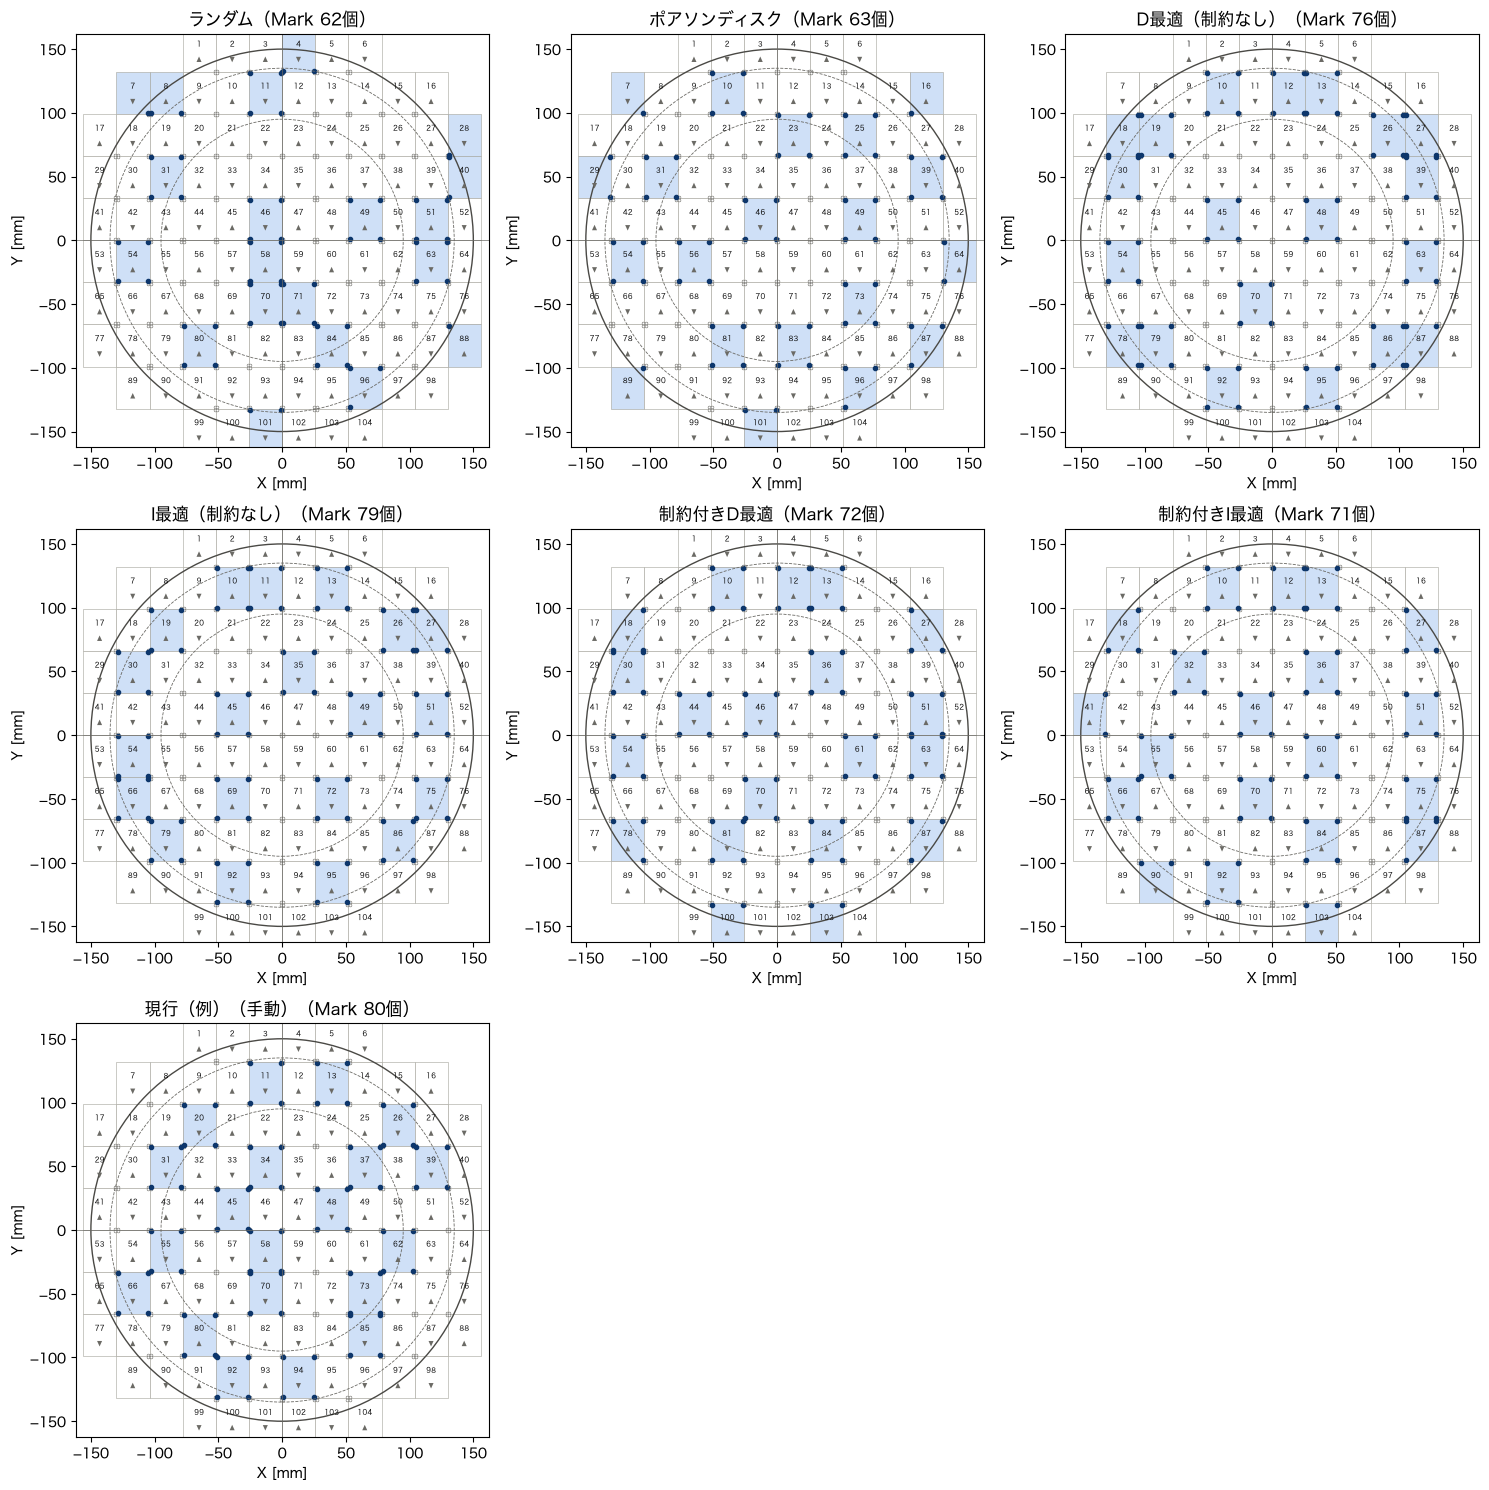

In [11]:
def representative_set(method_key):
    sets = [s for s in output["sets"] if s["method"] == method_key]
    ranked = sorted(sets, key=lambda s: np.nanmean(s["results"]["howa"]["x"]["rms"]))
    return ranked[(len(ranked) - 1) // 2]


methods = output["methods"]
columns = 3
figure, axes = plt.subplots(math.ceil(len(methods) / columns), columns, figsize=(5 * columns, 5 * math.ceil(len(methods) / columns)))
for ax, method in zip(axes.flat, methods):
    entry = representative_set(method["key"])
    plots.plot_selection_map(wafer_map, entry, title=f"{label_of(method)}（Mark {len(entry['markIndices'])}個）", zones=settings["zones"], ax=ax, mandatory_shot_indices=mandatory_shots)
for ax in list(axes.flat)[len(methods):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 7-3 推定誤差のマップ

未計測Markごとに、全Waferの推定誤差をRMSにして色で示します。Wafer端など、推定を外しやすい場所が分かります。

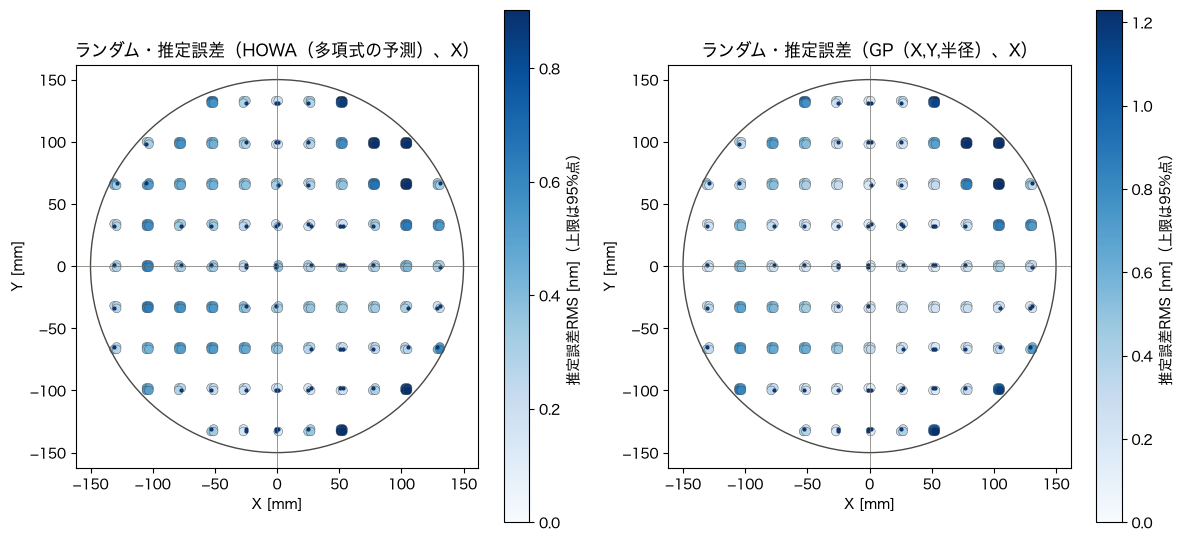

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plots.plot_estimation_error_map(output, "random", "howa", ax=axes[0])
plots.plot_estimation_error_map(output, "random", "gpXYR", ax=axes[1])
plt.tight_layout()
plt.show()

## 8. 計測点数のスイープ（トレードオフカーブ）

計測Shot数を変えながら評価します。比べる選び方は `sweep_settings["methods"]` で選びます（制約なしは破線、制約付きは実線）。手動プランは、そのMark数の位置に × で重ねます。時間を抑えるため、ここでは試行を5回にしています。

計測Mark数は選んだShotの有効なMarkの数の合計なので、端のShotを選ぶと選び方ごとに少し違います。横軸を計測Shot数にするときは `plots.plot_sweep(..., x_axis="shots")` です。

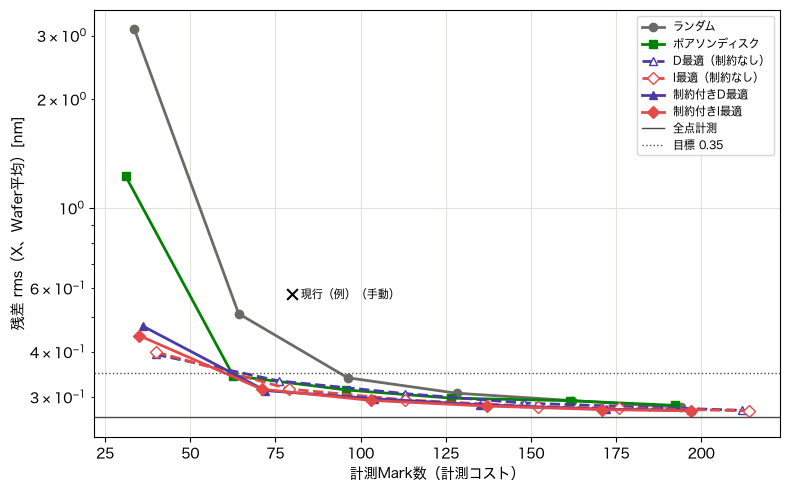

ランダム: 目標 0.35 nm に届く最小の計測Mark数 = 96（Shot 30）
ポアソンディスク: 目標 0.35 nm に届く最小の計測Mark数 = 63（Shot 20）
D最適（制約なし）: 目標 0.35 nm に届く最小の計測Mark数 = 76（Shot 20）
I最適（制約なし）: 目標 0.35 nm に届く最小の計測Mark数 = 79（Shot 20）
制約付きD最適: 目標 0.35 nm に届く最小の計測Mark数 = 72（Shot 20）
制約付きI最適: 目標 0.35 nm に届く最小の計測Mark数 = 71（Shot 20）


In [13]:
sweep_settings = {"startShots": 10, "endShots": 60, "stepShots": 10, "draws": 5, "methods": dict(settings["sweep"]["methods"])}
sweep = asc.run_sweep(wafer_map, data, settings, sweep_settings, manual_plans)
plots.plot_sweep(sweep, variant_key="howa", log_scale=True, target=0.35)
plt.tight_layout()
plt.show()

TARGET_NM = 0.35
for method in sweep["methods"]:
    reached = [p for p in sweep["points"] if "summary" in p and p["summary"][method["key"]]["variants"]["howa"]["x"]["rms"]["all"]["mean"] <= TARGET_NM]
    print(f"{method['label']}: 目標 {TARGET_NM} nm に届く最小の計測Mark数 =", f"{reached[0]['markCounts'][method['key']]:.0f}（Shot {reached[0]['shotCount']}）" if reached else "範囲内では届かない")

## 9. 結果をCSVで保存する

`output/` フォルダに、選び方 × 補正の集計と、選んだ点の一覧を保存します（Gitでは管理しません）。1つの選択点だけを保存するときは、4-2 のように `asc.selection_to_csv(wafer_map, entry["markIndices"])` を使います（列は ShotId, ShotX, ShotY, ScanDir, MarkNo, MarkX, MarkY, WaferX, WaferY）。

In [14]:
with open(OUTPUT_DIRECTORY / "summary.csv", "w", newline="", encoding="utf-8-sig") as file:
    writer = csv.writer(file)
    writer.writerow(["Method", "Correction", "Axis", "Metric", "Mean", "Median", "P95", "Max"])
    for method in output["methods"]:
        for variant in output["variants"]:
            for axis in ["x", "y"]:
                for metric in ["rms", "mean3sigma", "max"]:
                    stats = output["summary"][method["key"]]["variants"][variant["key"]][axis][metric]["all"]
                    writer.writerow([label_of(method), variant["label"], axis.upper(), metric, stats["mean"], stats["median"], stats["p95"], stats["max"]])

with open(OUTPUT_DIRECTORY / "selections.csv", "w", newline="", encoding="utf-8-sig") as file:
    writer = csv.writer(file)
    writer.writerow(["Method", "Draw", "ShotId", "MarkNo", "X_mm", "Y_mm"])
    for entry in output["sets"]:
        for mark_index in entry["markIndices"]:
            mark = wafer_map["marks"][mark_index]
            writer.writerow([entry["method"], entry["draw"] + 1, wafer_map["shots"][mark["shotIndex"]]["id"], mark["markNo"], mark["x"], mark["y"]])
print("保存しました:", sorted(p.name for p in OUTPUT_DIRECTORY.glob("*.csv")))

保存しました: ['plan_constrainedD.csv', 'plan_constrainedI.csv', 'selections.csv', 'summary.csv']


## 練習問題

1. 「Markが揃わない端のShotは選ばない」（`excludeIncompleteShots = True`）にし、計測Shot数を10にして評価してください。制約付きD最適と現行（例）の残差はどう変わるでしょうか。
2. 強制計測Shot（例: Wafer中心のまわりの4Shot）を指定して「計画を作る」を実行し、残りのShotがどこに足されるかを見てください。

下のセルに答えの書き方の例があります。

In [15]:
# 練習問題1の書き方の例（実行すると数秒かかります）
exercise = asc.copy_settings(settings)
exercise["sampling"]["excludeIncompleteShots"] = True
exercise["sampling"]["shotCount"] = 10
exercise["sampling"]["draws"] = 10
result = asc.run_evaluation(wafer_map, data, exercise, [])
for method in result["methods"]:
    print(method["label"], fmt(result["summary"][method["key"]]["variants"]["howa"]["x"]["rms"]["all"]["mean"]))

# 練習問題2の書き方の例（Shot番号はマップの図の番号）
exercise2 = asc.copy_settings(settings)
exercise2["constraints"]["mandatoryShotIds"] = ["46", "47", "58", "59"]
plan2 = asc.run_plan(wafer_map, exercise2)
print([wafer_map["shots"][i]["id"] for i in plan2["sets"][0]["shotIndices"]])

ランダム 7.345
ポアソンディスク 1.072
D最適（制約なし） 0.393
I最適（制約なし） 0.393
制約付きD最適 0.423
制約付きI最適 0.441


['46', '47', '58', '59', '18', '50', '10', '78', '97', '95', '100', '13', '42', '87', '81', '75', '54', '27', '39', '22']


## よくある間違いと発展

- **よくある間違い**: 計測Mark数が多項式の項数（初期設定では21項）より少ないと、HOWAが不安定になり残差が大きくなります。このときは警告が出ます（`output["sets"][i]["warnings"]`）。項数を減らすか、計測点を増やしてください。
- **発展**: MATLAB版（`matlab/` フォルダ）でも同じ設定で同じ結果になります。アプリで条件を決め、設定JSONを Python や MATLAB に渡して、細かい解析や大量の条件の計算に使えます。